Data shape: (488, 109)
Sample variation: min=0.0, max=61.0


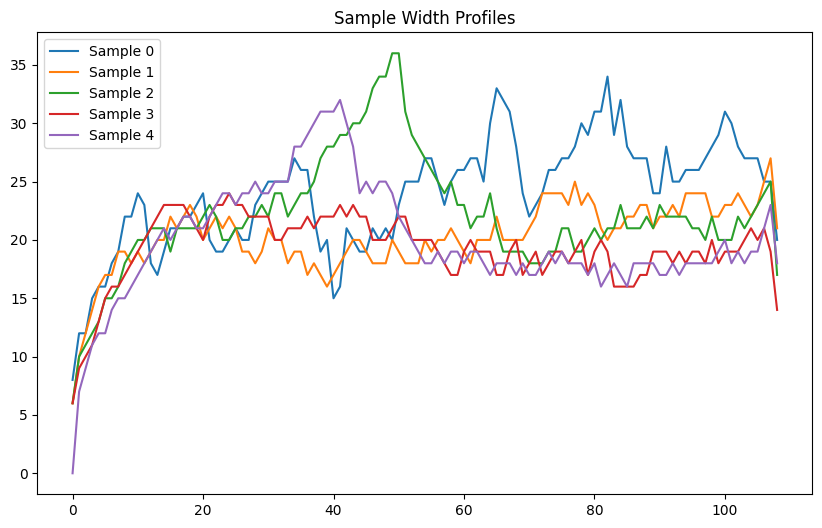

Computing DTW distances...
Processed 0/488 samples
Processed 10/488 samples
Processed 20/488 samples
Processed 30/488 samples
Processed 40/488 samples
Processed 50/488 samples
Processed 60/488 samples
Processed 70/488 samples
Processed 80/488 samples
Processed 90/488 samples
Processed 100/488 samples
Processed 110/488 samples
Processed 120/488 samples
Processed 130/488 samples
Processed 140/488 samples
Processed 150/488 samples
Processed 160/488 samples
Processed 170/488 samples
Processed 180/488 samples
Processed 190/488 samples
Processed 200/488 samples
Processed 210/488 samples
Processed 220/488 samples
Processed 230/488 samples
Processed 240/488 samples
Processed 250/488 samples
Processed 260/488 samples
Processed 270/488 samples
Processed 280/488 samples
Processed 290/488 samples
Processed 300/488 samples
Processed 310/488 samples
Processed 320/488 samples
Processed 330/488 samples
Processed 340/488 samples
Processed 350/488 samples
Processed 360/488 samples
Processed 370/488 samp

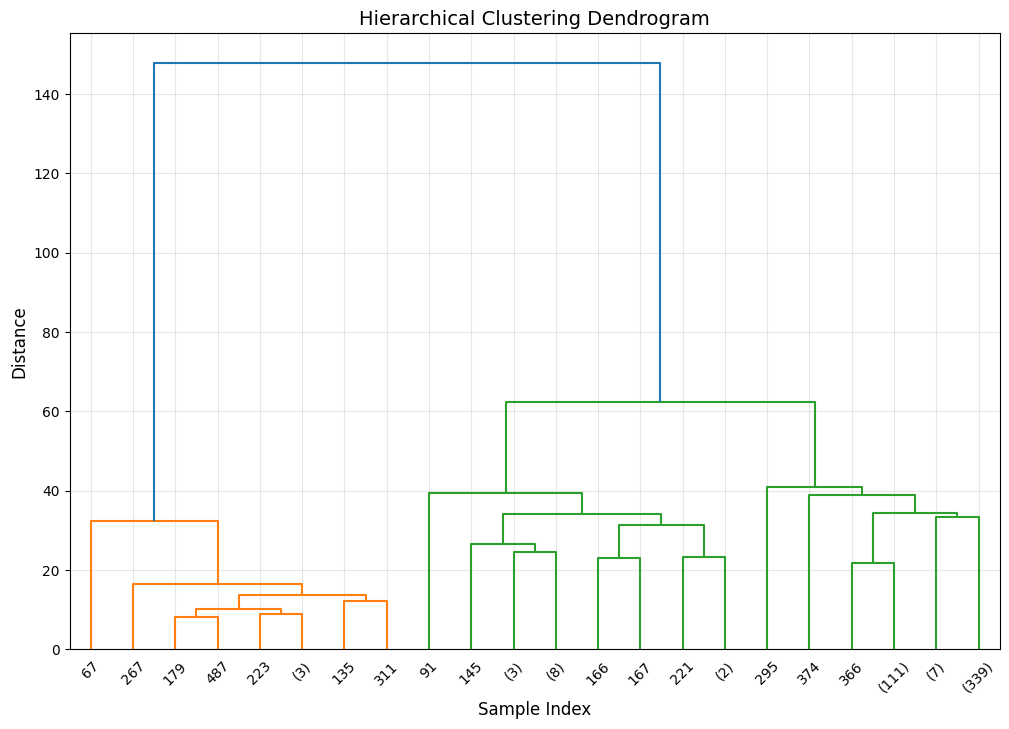


Cluster distribution:
0     10
1     18
2    460
Name: count, dtype: int64


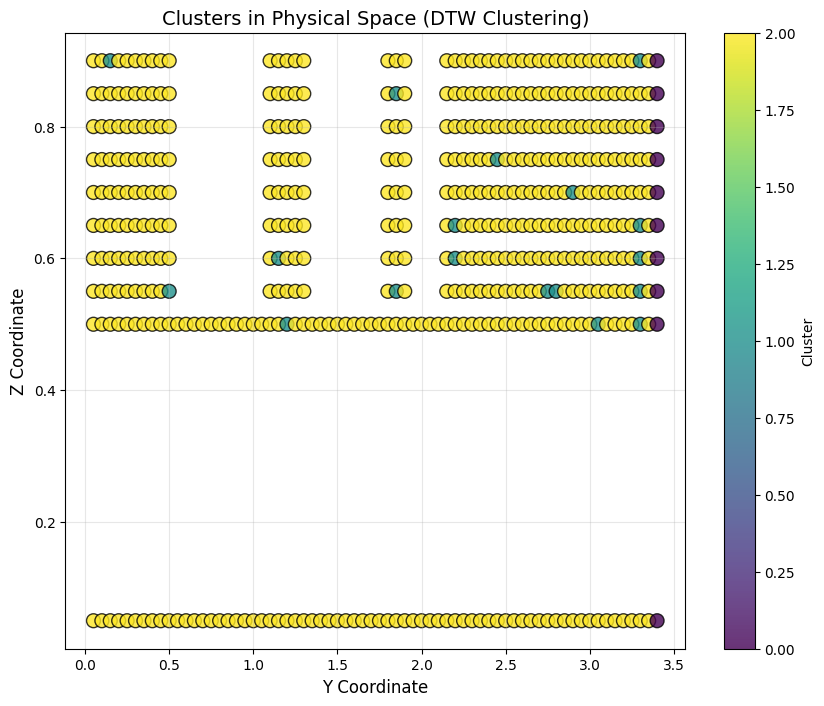

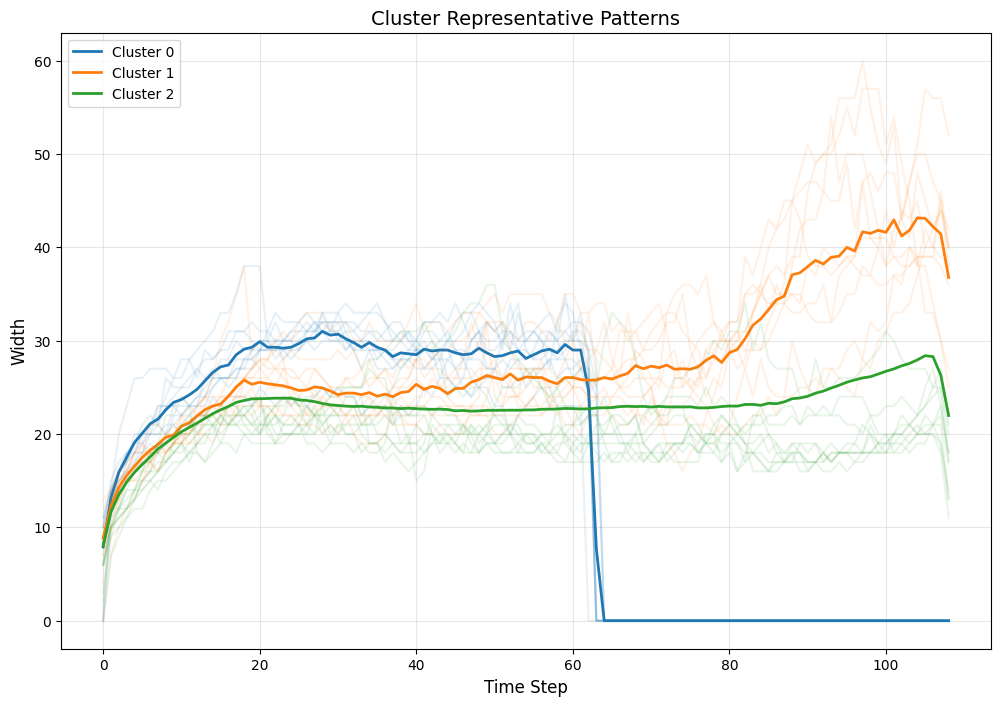

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from dtaidistance import dtw

# Load and prepare data
folder = './Data/'
file_path = os.path.join(folder, 'lengthConstant.csv')
df = pd.read_csv(file_path, header=None)

# Separate metadata from width measurements
metadata = df.iloc[:, :3].copy()
metadata.columns = ['y_coordinate', 'z_coordinate', 'power']
width_data = df.iloc[:, 3:].copy()

# Handle potential zeros or NaN values
width_data_clean = width_data.replace(0, np.nan)

# For DTW calculation, we need complete series (no NaN)
# Fill NaN with 0
width_array = width_data_clean.fillna(0).values

# Print data shape and check for variation
print(f"Data shape: {width_array.shape}")
print(f"Sample variation: min={width_array.min()}, max={width_array.max()}")

# Check first few rows to ensure data has variation
plt.figure(figsize=(10, 6))
for i in range(min(5, len(width_array))):
    plt.plot(width_array[i], label=f'Sample {i}')
plt.title('Sample Width Profiles')
plt.legend()
plt.show()

# Compute pairwise DTW distances using dtaidistance library
# This is more efficient than computing the full matrix
print("Computing DTW distances...")
n_samples = width_array.shape[0]
distances = np.zeros((n_samples, n_samples))

# Use a simpler DTW implementation
for i in range(n_samples):
    for j in range(i+1, n_samples):
        # Use the dtaidistance library for faster computation
        distance = dtw.distance(width_array[i], width_array[j])
        distances[i, j] = distance
        distances[j, i] = distance  # DTW is symmetric
    if i % 10 == 0:
        print(f"Processed {i}/{n_samples} samples")

# Check if distances have variation
dist_stats = {
    "min": np.min(distances[distances > 0]),  # Excluding zeros (self-distances)
    "max": np.max(distances),
    "mean": np.mean(distances[distances > 0]),
    "std": np.std(distances[distances > 0])
}
print(f"Distance statistics: {dist_stats}")

# Convert to condensed form for linkage
condensed_distances = squareform(distances)

# Apply hierarchical clustering
Z = linkage(condensed_distances, method='average')  # Use average linkage for DTW

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(
    Z, 
    truncate_mode='level',
    p=5,
    orientation='top',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Choose number of clusters (adjust based on dendrogram)
optimal_k = 3
cluster_labels = fcluster(Z, optimal_k, criterion='maxclust') - 1

# Add cluster labels to metadata
metadata['cluster'] = cluster_labels

# Show cluster distribution
print("\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# Visualize clusters in physical space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    metadata['y_coordinate'], 
    metadata['z_coordinate'],
    c=metadata['cluster'], 
    cmap='viridis',
    s=100, 
    alpha=0.8, 
    edgecolors='k'
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Y Coordinate', fontsize=12)
plt.ylabel('Z Coordinate', fontsize=12)
plt.title('Clusters in Physical Space (DTW Clustering)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Calculate representative patterns for each cluster (using mean for simplicity)
plt.figure(figsize=(12, 8))
for cluster_id in range(optimal_k):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_patterns = width_array[cluster_indices]
    mean_pattern = np.mean(cluster_patterns, axis=0)
    
    plt.plot(mean_pattern, linewidth=2, label=f'Cluster {cluster_id}')
    
    # Plot individual patterns with low opacity
    for idx in cluster_indices[:min(10, len(cluster_indices))]:  # Limit to 10 samples
        plt.plot(width_array[idx], alpha=0.1, color=plt.gca().lines[-1].get_color())
        
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Width', fontsize=12)
plt.title('Cluster Representative Patterns', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install dtaidistance
